# Polytropic ideal chemical reactors

Since most technically relevant chemical reactors are endo- or exothermic the thermal operation mode of chemical reactor plays and exceptional role in reactor design.
Hence, heat transfer between the reaction volume and the heating/cooling medium is one important design criterion, which can be adjusted by heat transfer area and coefficients.
However, the major challenge is that for reactor design the interplay of energy and material balances governs the actual degree of heat transfer requirement.
From mathematical perspective, the simultaneous solution of the resulting set of equations is challenging, since energy and material balance are coupled nonlinearly by the reaction rate equation.
Consequently, analytical solution is only possible for few very simplified cases and numerical solution strategies are mandatory for most practical relevant cases.
This assignment provides you with the numerical background and theoretical understanding of the required tools and results.

## Material and energy balance bSTR

The assignment illustrates the approach for a discontinuous stirred tank (batch) reactor operated unsteady-state. 
Assuming constant density of the reaction mixture, the following material balance can be deduced for a generic reaction network.

$$\frac{d c_i}{d t} = \sum_{j=1}^{M} \nu_{i,j} r_j $$

The equation reflects that the concentration changes over time, due to chemical reaction, while convective material exchange with the surrounding is absent.
Accordingly, the energy balance can be formulated as follows, where convective heat transport is absent, as well:

$$V_\text{R} \, \rho \, c_p \frac{d T}{d t} = - V_\text{R} \sum_{j=1}^M \Delta_R H_j \, r_j - h_{wall} A_{wall}(T-\overline{T}_{wall})$$

Hence, temperature of the reaction medium changes with time, due to heat release by chemical reaction (in exothermic case) and heat transfer to the wall.

The material and energy balance represent a system of ordinary differential equations (ODEs), which are coupled via the nonlinear reaction term.
In numerics terminology the set of equations resembel a initial value problem, which requires initial conditions for $c_i$ and $T$ to be solved.

For the rate of reaction $j$ we assume power-law for dependency on component concentration with the order $n_{i,j}$ and _Arrhenius_-expression for the temperature-dependency.

$$r_j = f(T,c_i) = k_{j\text{,0}} \exp \left(-\frac{E_{A,j}}{R\, T} \right) \prod_{i=1}^N c_i^{n_{i,j}}$$

For the background of these equations we refer to textbooks in the field of chemical reaction engineering, e.g. Güttel and Turek, Chemische Reaktionstechnik, Springer Spektrum, 2021.



## Example case

Let us assume a simple reaction
$A_1 \rightarrow A_2$ with a reaction enthalpy of $\Delta_R H = -200 \, kJ / mol$. The reaction mixture ($\rho = 900\,kg / m^3$) has a heat capacity of $c_p = 2.440 \, kJ / kg\, K$.
The kinetic parameters are $k_0 = 1 \cdot 10^{11}\, s^{-1}$ and $E_A=110\, kJ / mol$ with first order in component A ($n_A=1$). 
The reactor is approximately cylindrical with a diameter of $d_R = 2\, m$ and a filling level of the reaction $h = 2\, m$. 
The reaction mixture is cooled via the reactor wall with a heat transfer coefficient of $h_{wall} = 80 \, /W m^2 \, K$ and the temperature of the cooling medium of $\overline{T}_{wall} = 373\, K$. 
The initial temperature of the reaction mixture is $T_0=363\,K$ and the initial concentrations are $c_{1,0} = 600 \, mol/m^3$ and $c_{2,0} = 0$, respectively.

Since only one single reaction, but two components are required, the equations mentioned above can be applied as follows.
The reaction kinetics can be written as:
$$r = k_{0} \exp \left(-\frac{E_{A}}{R\, T} \right) c_1$$

The material balance equations for components $A_1$ and $A_2$ read as:
$$\frac{d c_1}{d t} = - r $$
$$\frac{d c_2}{d t} = r $$

For the energy balance the following equation holds:
$$V_\text{R} \, \rho \, c_p \frac{d T}{d t} = - V_\text{R} \Delta_R H \, r - h_{wall} A_{wall}(T-\overline{T}_{wall})$$

In addition, for cylindrical geometry we assume $ V_R = \frac{\pi}{4} d_R^2 $ and $A_{wall} = \pi\,d_R\,h$ (without the bottom area of the reactor).

In [15]:
#IMPORT SECTION
import numpy as np
import scipy.integrate as integ #important for initial value problem
import matplotlib.pyplot as plt #figures

#Parameters
E_A = 110000 #activation energy reaction 1 J/mol
k_0 = 1E11 # preexponential factor reaction 1 1/s
R = 8.314 #gas constant J/(mol K)
H_R = -92200 #reaction ethalpy reaction 1 J/mol

d_R = 0.03 #diameter of reactor m
h_R = 2.0 #height of reaction mixture

rho = 1000 #density reaction mixture kg/m^3
def rho_mix(T):
    return 1000-0.3^(T-423)
c_p =4190#heat capacity J/(kg K)
C=rho*c_p
def cp_mix(T):
    return 4190+0.5^(T-423)
    C=rho*cp_mix(T)

h_W = 0.5 #thermal transmittance W/(m^2 K)
hW_values = [0,1, 10, 100, 1000, 10000]
T0_values = [350, 400, 423, 450]
c10_values = [1000, 2270, 3000]
u_values = [1.0]
L = 300


# Initial conditions
c_10 = 2270#concentration mol/m^3
c_20 = 0#concentration mol/m^3
T_0 = 423#temperature of reaction mixture K
T_c = 423#temperature of thermal fluid K

#Precalculations
C = c_p*rho #heat capacity of reaction mixture J/(m^3 K)
A_R = np.pi*d_R*h_R #area for heat exchange with the wall m^2
V_R = (d_R/2)**2*np.pi*h_R #volume of reaction mixture m^3

def kinetics(T,c_E0):
    "Function for the reaction rate (Arrhenius, first order in c_1)"
    k_1 = k_0*np.exp(-E_A/(R*T)) # rate constant in 1/s
    r = k_1*c_E0 # reaction rate in mol/(m^3 s)
    return r

def PFTR(L,f):
    "Function for component balance and energy balance"
    # f is a vector containing concentrations of components (c_i) in mol/m^3 (f[0] and f[1]) and the temperature of the reaction mixture (f[2]) 
    c_E0 = f[0]
    c_EG = f[1]
    T = f[2]

    # reaction rate from kinetics function
    r = kinetics(T,c_E0)

    #differential equations
    dc_E0dL = -r #component balance c_E0
    dc_EGdL = r #component balance c_EG
    dTdL = (-H_R*r/C - h_W*A_R*(T-T_c)/(C*V_R)) #energy balance

    dfdL = np.empty_like(f)
    dfdL[0] = dc_E0dL
    dfdL[1] = dc_EGdL
    dfdL[2] = dTdL
    return dfdL

#Initial conditions
f_init = np.array([c_10,c_20,T_0])

#Solution
Lspan = np.array([0, 300])
Leval = np.linspace(0,Lspan[1],2001)
sol = integ.solve_ivp(PFTR, Lspan, f_init, method='BDF', t_eval =Leval)


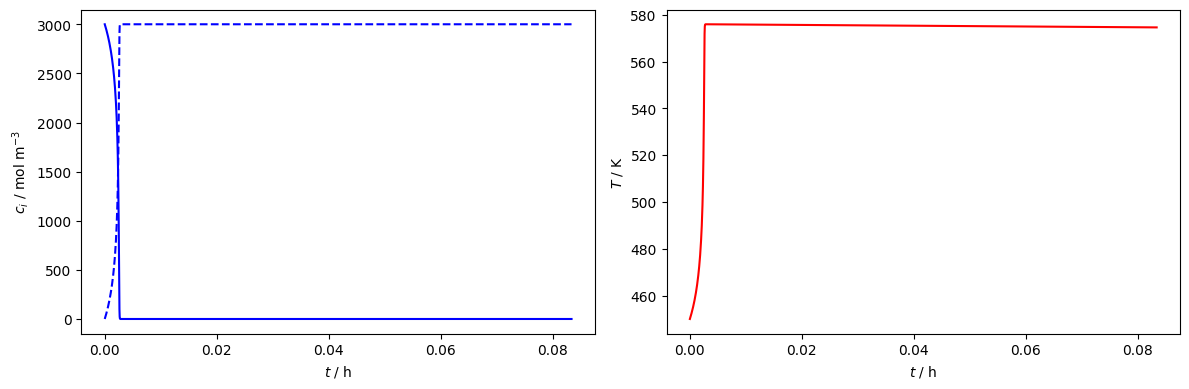

In [9]:
# POSTPROCESSING & PLOTTING
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.set(xlabel='$t$ / h', ylabel='$c_i$ / mol m$^{-3}$')
ax1.plot(sol.t/3600, sol.y[0,:], 'b-')
ax1.plot(sol.t/3600, sol.y[1,:], 'b--')

ax2.set(xlabel='$t$ / h', ylabel='$T$ / K')
ax2.plot(sol.t/3600, sol.y[2,:], 'r-')
fig.tight_layout()

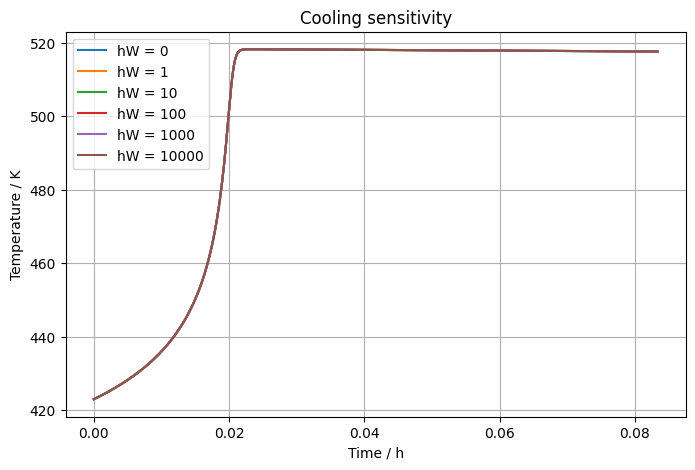

In [6]:
# Cooling sensitivity analysis

plt.figure(figsize=(8,5))

for h in hW_values:

    current_hW = h

    sol = integ.solve_ivp(
        bSTR,
        tspan,
        f_init,
        method='BDF',
        t_eval=teval
    )

    plt.plot(
        sol.t/3600,
        sol.y[2,:],
        label=f'hW = {h}'
    )

plt.xlabel('Time / h')
plt.ylabel('Temperature / K')
plt.title('Cooling sensitivity')
plt.legend()
plt.grid(True)
plt.show()

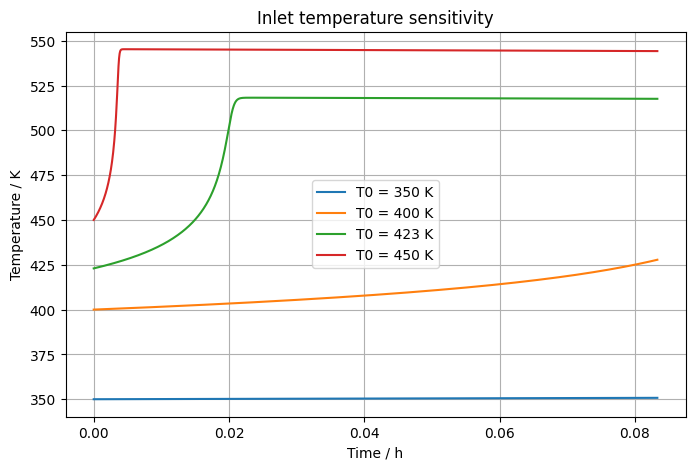

In [7]:
# Inlet temperature sensitivity analysis

plt.figure(figsize=(8,5))

for T in T0_values:

    # update inlet temperature
    T_0 = T

    # initial conditions
    f_init = np.array([c_10, c_20, T_0])

    # solve ODE
    sol = integ.solve_ivp(
        bSTR,
        tspan,
        f_init,
        method='BDF',
        t_eval=teval
    )

    # plot temperature
    plt.plot(
        sol.t/3600,
        sol.y[2,:],
        label=f'T0 = {T} K'
    )

plt.xlabel('Time / h')
plt.ylabel('Temperature / K')
plt.title('Inlet temperature sensitivity')
plt.legend()
plt.grid(True)
plt.show()

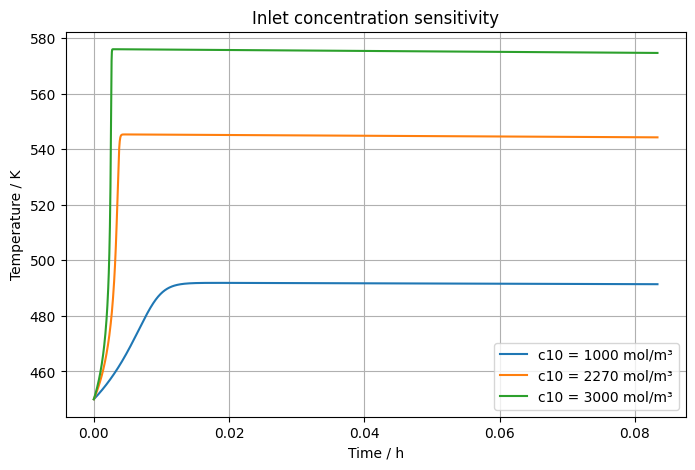

In [8]:
# Inlet concentration sensitivity analysis

plt.figure(figsize=(8,5))

for c in c10_values:

    # update inlet concentration
    c_10 = c

    # initial conditions
    f_init = np.array([c_10, c_20, T_0])

    # solve ODE
    sol = integ.solve_ivp(
        bSTR,
        tspan,
        f_init,
        method='BDF',
        t_eval=teval
    )

    # plot temperature
    plt.plot(
        sol.t/3600,
        sol.y[2,:],
        label=f'c10 = {c} mol/m³'
    )

plt.xlabel('Time / h')
plt.ylabel('Temperature / K')
plt.title('Inlet concentration sensitivity')
plt.legend()
plt.grid(True)
plt.show()

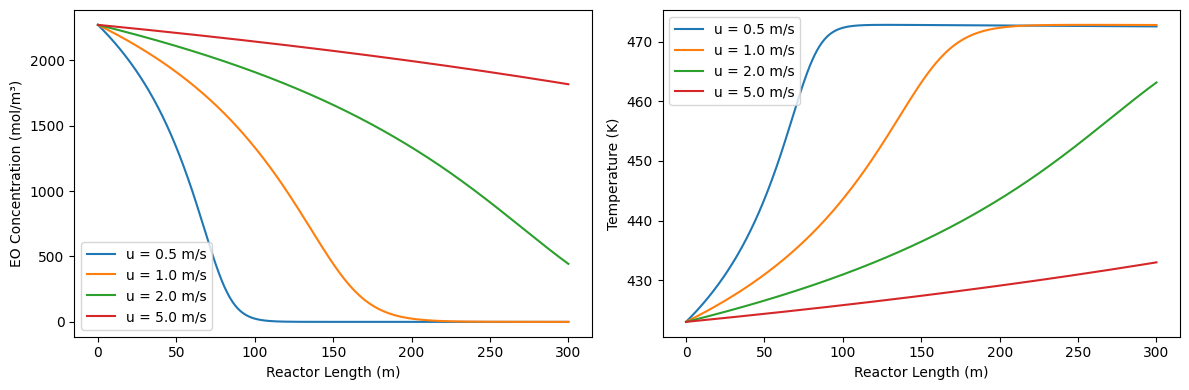

In [16]:
# Sensitivity Analysis: Effect of Fluid Velocity

u_values = [0.5, 1.0, 2.0, 5.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.set_xlabel('Reactor Length (m)')
ax1.set_ylabel('EO Concentration (mol/m³)')

ax2.set_xlabel('Reactor Length (m)')
ax2.set_ylabel('Temperature (K)')

for u in u_values:

    def PFTR(L, f):

        c_EO = f[0]
        c_EG = f[1]
        T = f[2]

        r = kinetics(T, c_EO)

        dc_EOdL = -r/u
        dc_EGdL = r/u
        dTdL = (-H_R*r/C - h_W*A_R*(T-T_c)/(C*V_R))/u

        dfdL = np.empty_like(f)
        dfdL[0] = dc_EOdL
        dfdL[1] = dc_EGdL
        dfdL[2] = dTdL

        return dfdL

    sol = integ.solve_ivp(
        PFTR,
        Lspan,
        f_init,
        method='BDF',
        t_eval=Leval
    )

    ax1.plot(sol.t, sol.y[0,:], label=f'u = {u} m/s')
    ax2.plot(sol.t, sol.y[2,:], label=f'u = {u} m/s')

ax1.legend()
ax2.legend()

plt.tight_layout()
plt.show()

The influence of fluid velocity on reactor performance was investigated. Lower velocities result in longer residence times, leading to higher ethylene oxide conversion and greater temperature rise. At higher velocities, the reactants spend less time inside the reactor, resulting in lower conversion and reduced temperature increase.

The simulation results for the given set of parameters are shown below. 
The concentration of component $A_1$ declines in principle, but the quantitative profile is unexpected for a simple first-order reaction.
This surprising oberservation can be explained by the raising temperature profile, which leads to a raise in the kinetic constant with time.
Hence, a rather complex profile for the reaction rate should evolve, which is affected by both $c_1$ and $T$.
It would be helpful to plot the respective profile as well, for tracing back the complex interactions leading to the observations in the current plot.

The temperature profile exhibits a clear hot-spot. 
Furthermore, the $T_{in}<\overline{T}_{wall}$, which leads to initial heating of the reaction mass, followed by cooling once $T=\overline{T}_{wall}$.
Here the question arises, which parameters affect the temperature profile and how certain values have to be chosen to modify the profile.
Since concentration and temperature profiles are linked, the challenge is that the proper choice of modifications is not necessarily straight-forward.
The chance, however, is that one might be able to reduce the reaction time to reach the desired conversion by altering the temperature profile.

These ideas could be elaborated in the assignment.

## Assignment Tasks

The background above illustrates the solution of an **initial value problem** using the example of a **polytropic** discontinuous stirred tank (batch) reactor, which is operated in unsteady-state.
However, plug-flow tubular reactors (PFTR) operated in steady-state are also catagorized as initial value problems from mathematical perspective.
From theoretical chemical engineering standpoint, the reaction time in the batch reactor $t_R$ is identical to the mean residence time in the PFTR $\overline{\tau}$ (in terms of an abstract viewpoint). 
Using the constant fluid velocity $u$ the transformation of the spatial coordinate $z$ in the tubular reactor into the temporal coordinate $t$ in the batch reactor can be done (space-time transformation).
Hence, numerical solution of both problems can be achieved by using the same mathematical framework.

The specific task aims at transforming the example for the batch reactor and application to a specific reaction carried out in a PFTR. In the specific case the exothermic hydrolysis of ethylene oxide (EO) with water to ethylene glycol (EG) is considered ($EO+H_2O \rightarrow EG$). The kinetic expression is written as:

\begin{equation}
k(T)=5.01\cdot \exp\left(-\frac{72500\;\mathrm{J\,mol^{-1}}}{R\,T}\right)\;\mathrm{s^{-1}}.
\end{equation}

The following parameters are known:

| Quantity | Symbol | Default |
| --- | --- | --- |
| Fluid velocity | $u$ | $1\,\mathrm{m\,s^{-1}}$ |
| EO inlet concentration | $c_{\mathrm{EO},in}$ | $2.27\,\mathrm{mol\,L^{-1}}$ |
| Inlet temperature | $T_{in}$ | $423\,\mathrm{K}$ |
| Reaction enthalpy | $\Delta_\mathrm{R}H$ | $-92.2\,\mathrm{kJ\,mol^{-1}}$ |
| Density | $\rho$ | $1000\,\mathrm{kg\,m^{-3}}$ |
| Heat capacity | $c_p$ | $4.19\,\mathrm{kJ\,kg^{-1}\,K^{-1}}$ |
| Tube diameter | $d_\mathrm{R}$ | $0.03\,\mathrm{m}$ |
| Wall heat-transfer coefficient | $h_\mathrm{wall}$ | $0.5\,\mathrm{kJ\,s^{-1}\,m^{-2}\,K^{-1}}$ |
| Wall temperatures | $T_\mathrm{wall}$ | $423\,\mathrm{K}$ |
| Reactor length | $L$ | $300\,\mathrm{m}$ |


In order to fulfill the assignment, the following tasks should be achieved:
* research required information, e.g. alternative reaction conditions, data for validation, design equations
* discuss the mathematical modification needed to adapt generic PFTR-relevant equations the given application case
* verify of the implementation with a meaningful strategy (implementation itselft may be supported by AI)
* vary the process and reactor design parameters and discuss the results on subject-specific basis (scientifically)
* derive conclusions, e.g. on design aspects and operation of suitable reactors with brief comparison to industrial practice
You may elaborate a bit on the comparison between batch and PFTR with respect to suitability for the given reaction, the degrees of freedom for reactor design, etc.

## Learning aims

The students are able to
* solve initial value problems numerically using the example of ideal polytropic reactors.
* understand the similarities and differences between various types of ideal chemical reactors.
* understand, analyze and discuss behaviour modes of polytropc reactors.
* select and depict relevant results for the subject-specific discussion.
* use suitable digital tools for solving typical problems in chemical reaction engineering in a reflected manner.

## Hints

1. The mathematical approach and implementation should be described in sufficient detail, in order to rate the correctness of the approach. Since the assignment deepens knowledge from Bachelor eductation, you do not need to provide the detailed derivation of the equations. Instead, you can refer to well-know textbook knowledge and describe extensions or specifications, which are necessary for the solution approach.
2. The example above emphazises the mathematical approach and implementation for you as a working basis, but keeps the verification and scientific discussions short. Your focus should, therefore, be the opposite.
3. You are free to use AI for Python coding. However, you should be able to explain the code and find potential errors.
4. In case you use AI keep in mind that the tool does not check for validity, hence you should put significant effort for convincing verification.
5. Before submission of the assignment, run the overall notebook once. In case implementation errors are present, you have than the chance to correct them.

# General comments

The text and code above is intended to provide you with the subject-specific background to the assignment, the principle approach to the solution and working code examples. You do **not** have to reproduce the background and the equations. Instead, focus on the adaptions you made to the approach and the code in order to solve the assignment. Furthermore, you may extent the depth of the result discussion.

The code is intended to provide you a working basis. It is therefore tested to work, but is not optimized. So, feel free to provide improved coding, if you like. You should focus on the chemical reaction engineering dimension of the assignment, though.

## Use of AI tools in this assignment

The use of AI tools (e.g. ChatGPT, Claude, Gemini, GitHub Copilot, Perplexity) is **explicitly permitted**, but must be reflected and documented. The full course methodology is provided in a separate handout; the points below summarise what applies to every assignment.

**Permissible:** code generation and debugging, verification strategies, concept explanation for self-study, identification of literature, language editing.

**Not permissible:** AI must not be used to provide the *intellectual structure of the argumentation* — i.e. the line of reasoning of the discussion, the derivation of conclusions, or the engineering judgement underlying design and operation decisions. AI use for text production is restricted to proof-reading and language polishing, once the substance has been formulated by you.

**You remain fully responsible** for correctness. Errors in AI outputs that you fail to detect — particularly in thermodynamic data, kinetic parameters, literature references and code — are attributed to you.

### Required documentation

Add a section **"AI use and reflection"** near the end of your report covering:

1. **Tools used** — name, model/version, date.
2. **Areas of use** — for which subtasks (research, code, debugging, verification, interpretation, language editing).
3. **Prompting strategy** — structure and logic of your prompting workflow for substantive use.
4. **Critical examination** — verification against authoritative sources, plausibility checks, unit consistency, errors detected and corrected.
5. **Statement of own contribution** — which parts of the scientific reasoning are your independent work.

**Mandatory appendix:** if AI has been used beyond purely linguistic editing, attach the verbatim chat protocol(s) as a separate PDF file alongside your main report.

## Grading

Grading is primarily based on subject-specific intellectual input, scientific depth and rigour. The AI documentation itself is enters to the assessment as follows:

* **Reflective documentation** of AI use is expected; incomplete documentation is treated as a deficiency in scientific rigour.
* **Critical engagement** with AI outputs (errors identified and corrected, independent validation) is credited positively.
* **Uncritical adoption** (fabricated references, unverified data, implausible results, superficial discussion) is reflected negatively, whether declared or not.
* **Undeclared** AI use is treated as undisclosed sources and may lead to failing the assignment.

In case of doubt, contact the course staff before submission — clarification before the deadline is always possible and welcome.
We also refer to the more extensive guideline to the use and documentation of AI tools, since we provide a minimal version here, only.